# Initial benchmark results

Run `uv sync --extra dataset --extra dev --extra analysis`, open this notebook with the project's `.venv` kernel, and change `BATCH_DIR` below to inspect another batch. The notebook reads saved JSON only; it does not run agents, judges, or Docker. The two detailed tables are also saved as PNG images in `notebooks/figures/` for slides.

Run-level detection and individual test outcomes have different denominators. A *detection* is one compliant run with at least one test that fails on buggy and passes on golden. The four paired-test cells count only tests with completed binary results on both versions.

In [19]:
import json
from collections import Counter
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import PercentFormatter

PAPER = '#f7f9fc'
INK = '#263247'
MUTED = '#66758c'
GRID = '#dfe6ef'
SUCCESS = '#168a78'
AMBER = '#e8a258'
plt.rcParams.update({
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'savefig.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'font.size': 11, 'figure.dpi': 120,
})

def show_results_table(title, headers, records, widths, height, image_path):
    figure_width = 18
    if not records:
        records = [['No saved results', *([None] * (len(headers) - 1))]]
    cell_text = []
    for record in records:
        formatted_row = []
        for column, (value, width, header) in enumerate(zip(record, widths, headers)):
            label = str(value) if value is not None else '—'
            if column != 0 and header != 'Run ID':
                label = label.replace('_', ' ')
            formatted_row.append(fill(label, width=max(12, int(figure_width * width * 9)),
                                      break_long_words=False))
        cell_text.append(formatted_row)
    fig = plt.figure(figsize=(figure_width, height), facecolor='white')
    fig.text(0.025, 0.94, title, fontsize=19, fontweight='bold', color=INK)
    fig.text(0.025, 0.025, f'Batch {BATCH_DIR.name}', fontsize=9, color=MUTED)
    ax = fig.add_axes([0.025, 0.08, 0.95, 0.78])
    ax.axis('off')
    table = ax.table(cellText=cell_text, colLabels=headers, colWidths=widths,
                     cellLoc='left', colLoc='left', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor('#dfe6ef')
        cell.set_linewidth(0.6)
        cell.PAD = 0.07
        cell.set_facecolor(INK if row == 0 else ('#f3f7fb' if row % 2 == 0 else 'white'))
        cell.get_text().set_color('white' if row == 0 else INK)
        if row == 0 or column == 0:
            cell.get_text().set_fontweight('bold')
    image_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(image_path, dpi=180, facecolor='white')
    plt.show()

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent  # Notebook kernels may start in notebooks/.
BATCH_DIR = PROJECT_ROOT / 'batches' / '20260923T220231Z-087f21ff'
summary = json.loads((BATCH_DIR / 'summary.json').read_text())

rows = []
for job in summary['jobs']:
    run_path = None
    if job.get('run_dir'):
        saved_path = Path(job['run_dir'])
        run_path = saved_path if saved_path.is_dir() else PROJECT_ROOT / 'runs' / saved_path.name
    result_path = run_path / 'generation' / 'result.json' if run_path else None
    generation = json.loads(result_path.read_text()) if result_path and result_path.is_file() else {}
    judge = job.get('judge', {})
    no_tests = job.get('buggy_status') == job.get('golden_status') == 'no_tests'
    judge_outcome = (
        # Older runs judged no-test submissions; the pipeline now skips them.
        'skipped' if no_tests
        else judge.get('tests_issue', 'missing')
        if judge.get('status') == 'completed' else judge.get('status', 'missing')
    )
    rows.append({
        **job,
        'run_id': run_path.name if run_path else None,
        'harness': generation.get('harness', 'unknown'),
        'agent_status': generation.get('status', 'missing'),
        'no_tests': no_tests,
        'problem': job.get('instance_id') or Path(job['config']).stem,
        'judge_outcome': judge_outcome,
    })

completed = [r for r in rows if r.get('buggy_status') == r.get('golden_status') == 'completed']
print(f"Batch: {BATCH_DIR.name} | runs: {len(rows)} | completed pairs: {len(completed)}")
print(f"Detected runs: {sum(r.get('detected', False) for r in completed)}")

Batch: 20260923T220231Z-087f21ff | runs: 15 | completed pairs: 13
Detected runs: 2


## Run status

One row per run. `Generation` is the agent's own status; a `timeout` run is still evaluated on whatever tests it wrote. `no tests` means neither version collected a generated test, so the run has no paired results and no judgment.

In [ ]:
show_results_table(
    'Run status',
    ['Problem', 'Harness', 'Run ID', 'Generation', 'Buggy eval', 'Golden eval',
     'Run state', 'Detected'],
    [
        [r['problem'], r['harness'], r['run_id'], r['agent_status'],
         r.get('buggy_status'), r.get('golden_status'), r.get('state'),
         'yes' if r.get('detected') else 'no']
        for r in sorted(rows, key=lambda r: (r['problem'], r['harness']))
    ],
    [0.22, 0.08, 0.18, 0.10, 0.10, 0.10, 0.14, 0.08], 1.5 + 0.45 * len(rows),
    PROJECT_ROOT / 'notebooks' / 'figures' / f'{BATCH_DIR.name}-run-status.png',
)
print(Counter(r['agent_status'] for r in rows))

## Run-level detection

The dot plot uses completed buggy/golden pairs as its denominator. The grid shows **detections / completed pairs** for each problem–harness combination; amber means no complete pair, labelled with the reason. Runs without a complete pair are excluded from rates, not counted as failures.

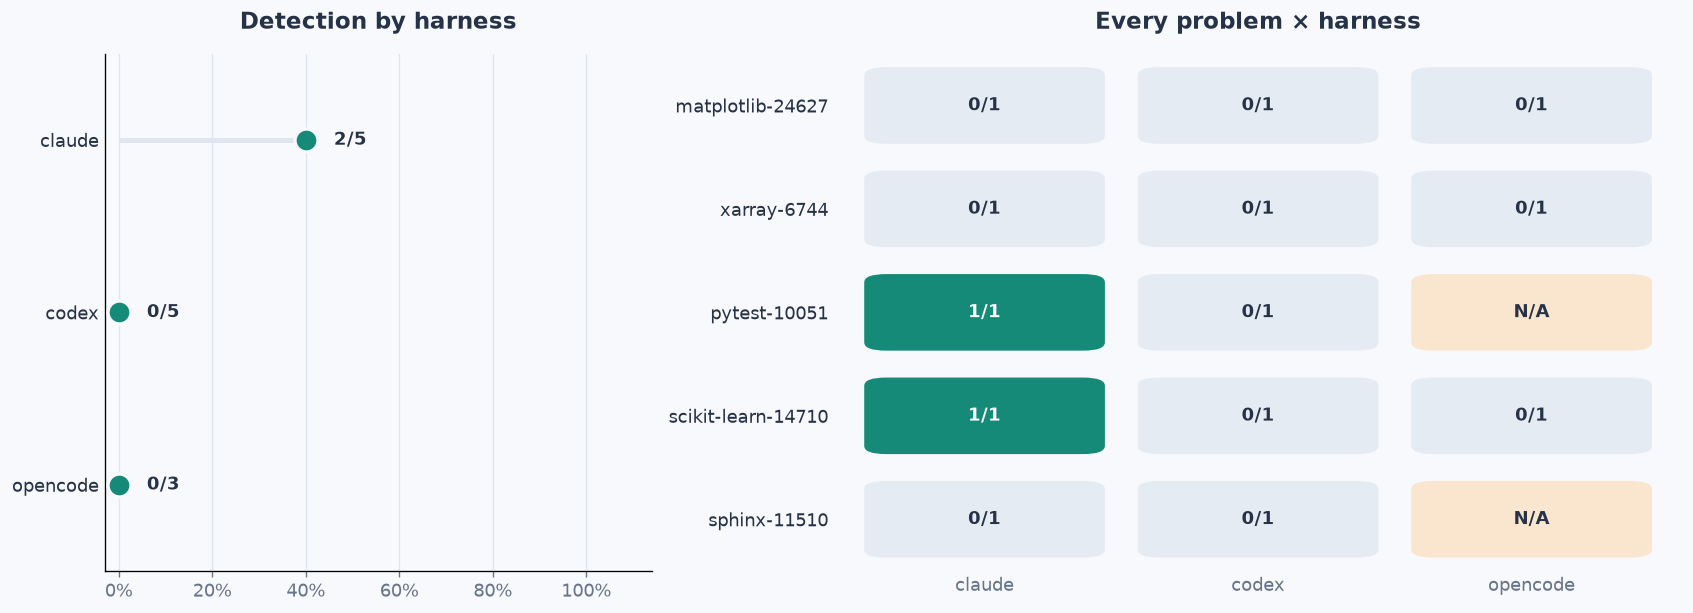

Excluded incomplete pairs: 2


In [20]:
harnesses = sorted({r['harness'] for r in rows if r['run_id']})
problems = sorted({r['problem'] for r in rows})
fig, (rate_ax, grid_ax) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.55]}, layout='constrained'
)
for y, harness in enumerate(harnesses):
    paired = [r for r in completed if r['harness'] == harness]
    yes = sum(r.get('detected', False) for r in paired)
    rate = yes / len(paired) if paired else 0
    rate_ax.hlines(y, 0, rate, color=GRID, linewidth=3)
    rate_ax.scatter(rate, y, s=190, color=SUCCESS, edgecolor=PAPER, linewidth=2, zorder=3)
    rate_ax.text(rate + 0.06, y, f'{yes}/{len(paired)}', va='center', fontweight='bold')
rate_ax.set(title='Detection by harness', xlim=(-0.03, 1.14), ylim=(len(harnesses) - 0.5, -0.5))
rate_ax.set_yticks(range(len(harnesses)), harnesses)
rate_ax.xaxis.set_major_formatter(PercentFormatter(1))
rate_ax.grid(axis='x', color=GRID, linewidth=0.8)
rate_ax.set_axisbelow(True)
rate_ax.tick_params(axis='y', length=0)

for y, problem in enumerate(problems):
    for x, harness in enumerate(harnesses):
        matches = [r for r in rows if r['problem'] == problem and r['harness'] == harness]
        paired = [r for r in matches if r.get('buggy_status') == r.get('golden_status') == 'completed']
        yes = sum(r.get('detected', False) for r in paired)
        color = SUCCESS if yes else ('#e5ebf2' if paired else '#fae6ce')
        if paired:
            label = f'{yes}/{len(paired)}'
            timeouts = sum(r['agent_status'] == 'timeout' for r in paired)
            if timeouts:
                label += f'\n{timeouts} timed out'
        elif matches:
            label = '\n'.join(sorted({
                'NO TESTS' if r['no_tests'] else str(r.get('buggy_status')).upper()
                for r in matches
            }))
            if any(r['agent_status'] == 'timeout' for r in matches):
                label += '\n(timeout)'
        else:
            label = '—'
        tile = FancyBboxPatch((x - 0.42, y - 0.35), 0.84, 0.70,
                              boxstyle='round,pad=0.02,rounding_size=0.08',
                              facecolor=color, edgecolor='none')
        grid_ax.add_patch(tile)
        grid_ax.text(x, y, label, ha='center', va='center',
                     color='white' if yes else INK, fontweight='bold')
grid_ax.set(title='Every problem × harness', xlim=(-0.55, len(harnesses) - 0.45),
            ylim=(len(problems) - 0.5, -0.5))
grid_ax.set_xticks(range(len(harnesses)), harnesses)
grid_ax.set_yticks(range(len(problems)), [p.split('__')[-1] for p in problems])
grid_ax.tick_params(length=0)
for spine in grid_ax.spines.values():
    spine.set_visible(False)
plt.show()
print(f"Excluded incomplete pairs: {len(rows) - len(completed)}")

## Paired generated-test outcomes

Each heatmap cell is the **share of completed paired tests** in that outcome; `n` is the number of paired tests in its row. This is not a run success rate. `Pass both` means only that the test did not distinguish the revisions. Skips, collection errors, and incomplete executions are excluded.

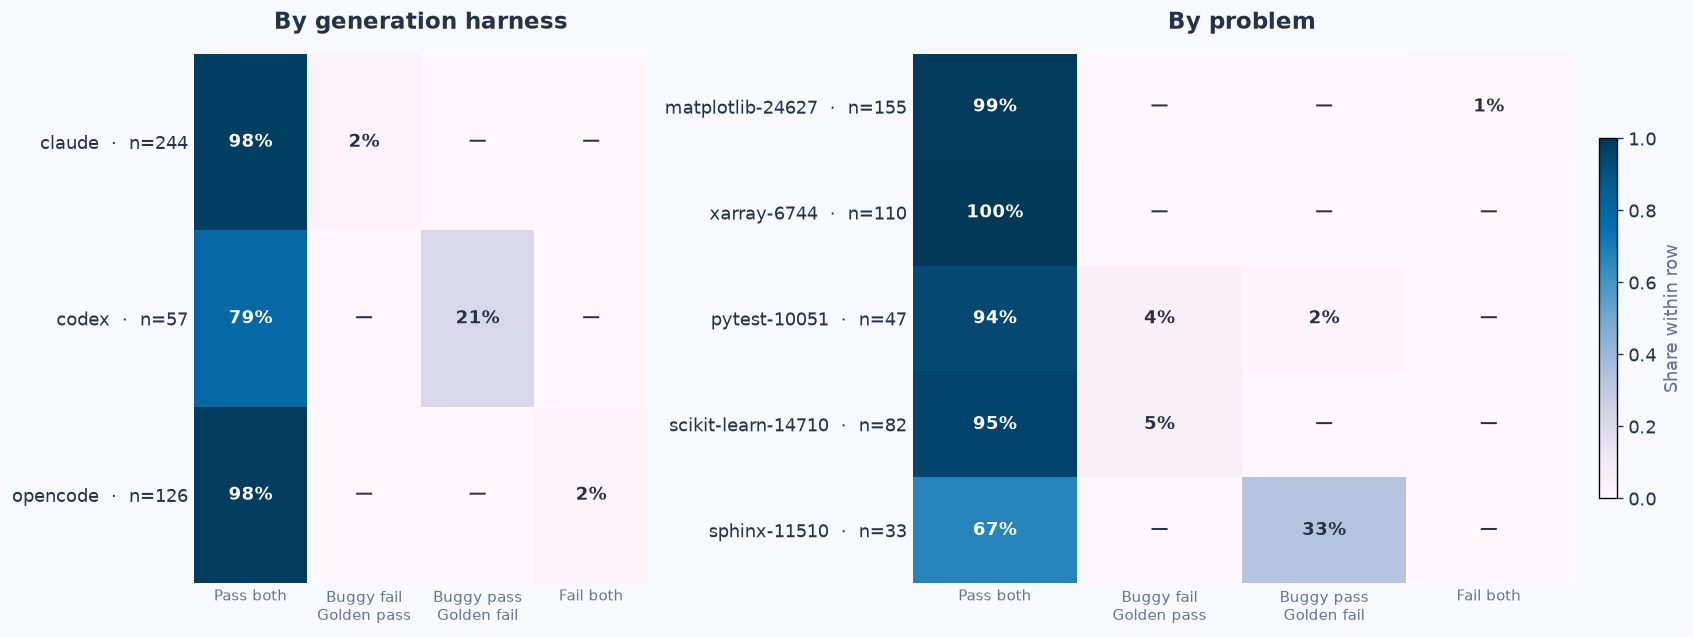

In [21]:
cells = [
    ('pass_on_both', 'Pass both'),
    ('fail_on_buggy_pass_on_golden', 'Buggy fail\nGolden pass'),
    ('pass_on_buggy_fail_on_golden', 'Buggy pass\nGolden fail'),
    ('fail_on_both', 'Fail both'),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2),
                         gridspec_kw={'width_ratios': [1, 1.45]}, layout='constrained')
for ax, field, title in [
    (axes[0], 'harness', 'By generation harness'),
    (axes[1], 'problem', 'By problem'),
]:
    labels = sorted({r[field] for r in completed})
    counts = [
        [sum(r.get('matrix', {}).get(key, 0) for r in completed if r[field] == name)
         for key, _ in cells]
        for name in labels
    ]
    totals = [sum(row) for row in counts]
    shares = [[count / total if total else 0 for count in row]
              for row, total in zip(counts, totals)]
    image = ax.imshow(shares, cmap='PuBu', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(cells)), [label for _, label in cells], fontsize=9)
    ax.set_yticks(range(len(labels)),
                  [f"{name.split('__')[-1]}  ·  n={total}" for name, total in zip(labels, totals)])
    ax.tick_params(length=0)
    for y, row in enumerate(shares):
        for x, share in enumerate(row):
            label = '—' if totals[y] == 0 or share == 0 else (f'{share:.1%}' if share < 0.01 else f'{share:.0%}')
            ax.text(x, y, label, ha='center', va='center',
                    color='white' if share > 0.55 else INK, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.colorbar(image, ax=axes, shrink=0.68, pad=0.02, label='Share within row')
plt.show()

## Generated-test judgments

The judge asks whether any generated test **attempts to test the issue**. This is distinct from matrix detection. The ring summarizes all judge answers and execution statuses; its center counts only valid ratings. The grid shows the answer for each run, including failures rather than treating them as `no`. `Skipped` marks runs with no collected tests, which have nothing to judge. The table below gives each run's branch-specific detail and cheating label; a dash marks an inapplicable or missing answer.

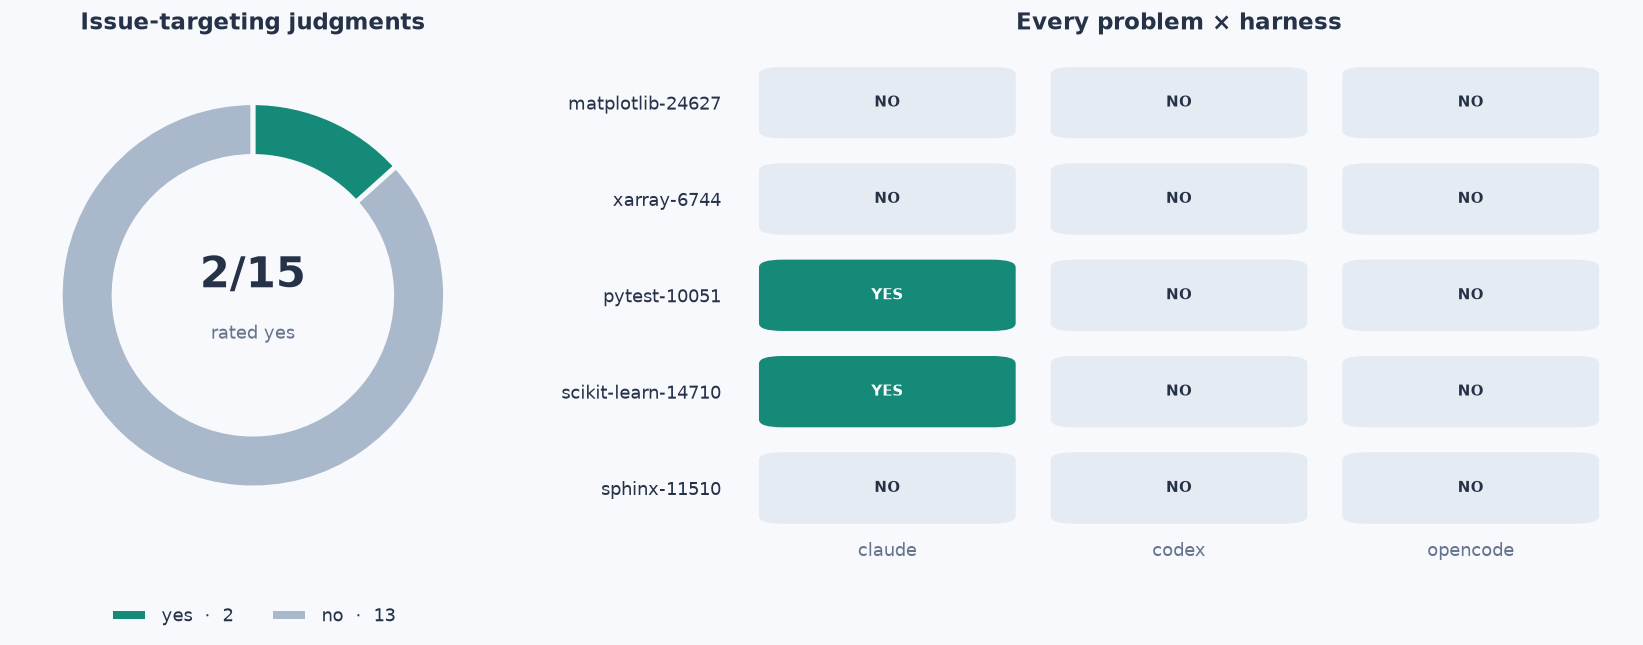

In [22]:
judge_rows = [r for r in rows if r['run_id']]
answer_counts = Counter(r['judge_outcome'] for r in judge_rows)
answer_colors = {'yes': SUCCESS, 'no': '#a9b8ca', 'unsure': AMBER,
                 'failed': '#e47777', 'timed_out': '#e47777', 'skipped': '#d5dce6'}
labels = [label for label in ('yes', 'no', 'unsure') if answer_counts[label]]
labels += [label for label in sorted(answer_counts) if label not in labels]
fig, (ring_ax, grid_ax) = plt.subplots(
    1, 2, figsize=(14, 5.3), gridspec_kw={'width_ratios': [1, 1.55]}, layout='constrained'
)
wedges, _ = ring_ax.pie([answer_counts[label] for label in labels],
                         colors=[answer_colors.get(label, '#b79ac7') for label in labels],
                         startangle=90, counterclock=False,
                         wedgeprops={'width': 0.28, 'edgecolor': PAPER, 'linewidth': 3})
valid = sum(answer_counts[label] for label in ('yes', 'no', 'unsure'))
ring_ax.text(0, 0.1, f"{answer_counts['yes']}/{valid}", ha='center', va='center',
             fontsize=26, fontweight='bold', color=INK)
ring_ax.text(0, -0.20, 'rated yes', ha='center', va='center', color=MUTED)
ring_ax.set_title('Issue-targeting judgments')
ring_ax.legend(wedges, [f'{label}  ·  {answer_counts[label]}' for label in labels],
               loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)

for y, problem in enumerate(problems):
    for x, harness in enumerate(harnesses):
        matches = [r for r in judge_rows if r['problem'] == problem and r['harness'] == harness]
        if len(matches) == 1:
            outcome = matches[0]['judge_outcome']
            label = 'SKIPPED\n(no tests)' if outcome == 'skipped' else outcome.upper().replace('_', ' ')
        else:
            outcome = 'mixed' if matches else 'missing'
            label = f"{sum(r['judge_outcome'] == 'yes' for r in matches)}/{len(matches)} YES" if matches else '—'
        color = {'yes': SUCCESS, 'no': '#e5ebf2', 'unsure': '#fae6ce',
                 'failed': '#fadbd9', 'skipped': '#f3f5f8'}.get(outcome, '#e9e5f2')
        tile = FancyBboxPatch((x - 0.42, y - 0.35), 0.84, 0.70,
                              boxstyle='round,pad=0.02,rounding_size=0.08',
                              facecolor=color, edgecolor='none')
        grid_ax.add_patch(tile)
        grid_ax.text(x, y, label, ha='center', va='center', fontsize=9,
                     color='white' if outcome == 'yes' else INK, fontweight='bold')
grid_ax.set(title='Every problem × harness', xlim=(-0.55, len(harnesses) - 0.45),
            ylim=(len(problems) - 0.5, -0.5))
grid_ax.set_xticks(range(len(harnesses)), harnesses)
grid_ax.set_yticks(range(len(problems)), [p.split('__')[-1] for p in problems])
grid_ax.tick_params(length=0)
for spine in grid_ax.spines.values():
    spine.set_visible(False)
plt.show()

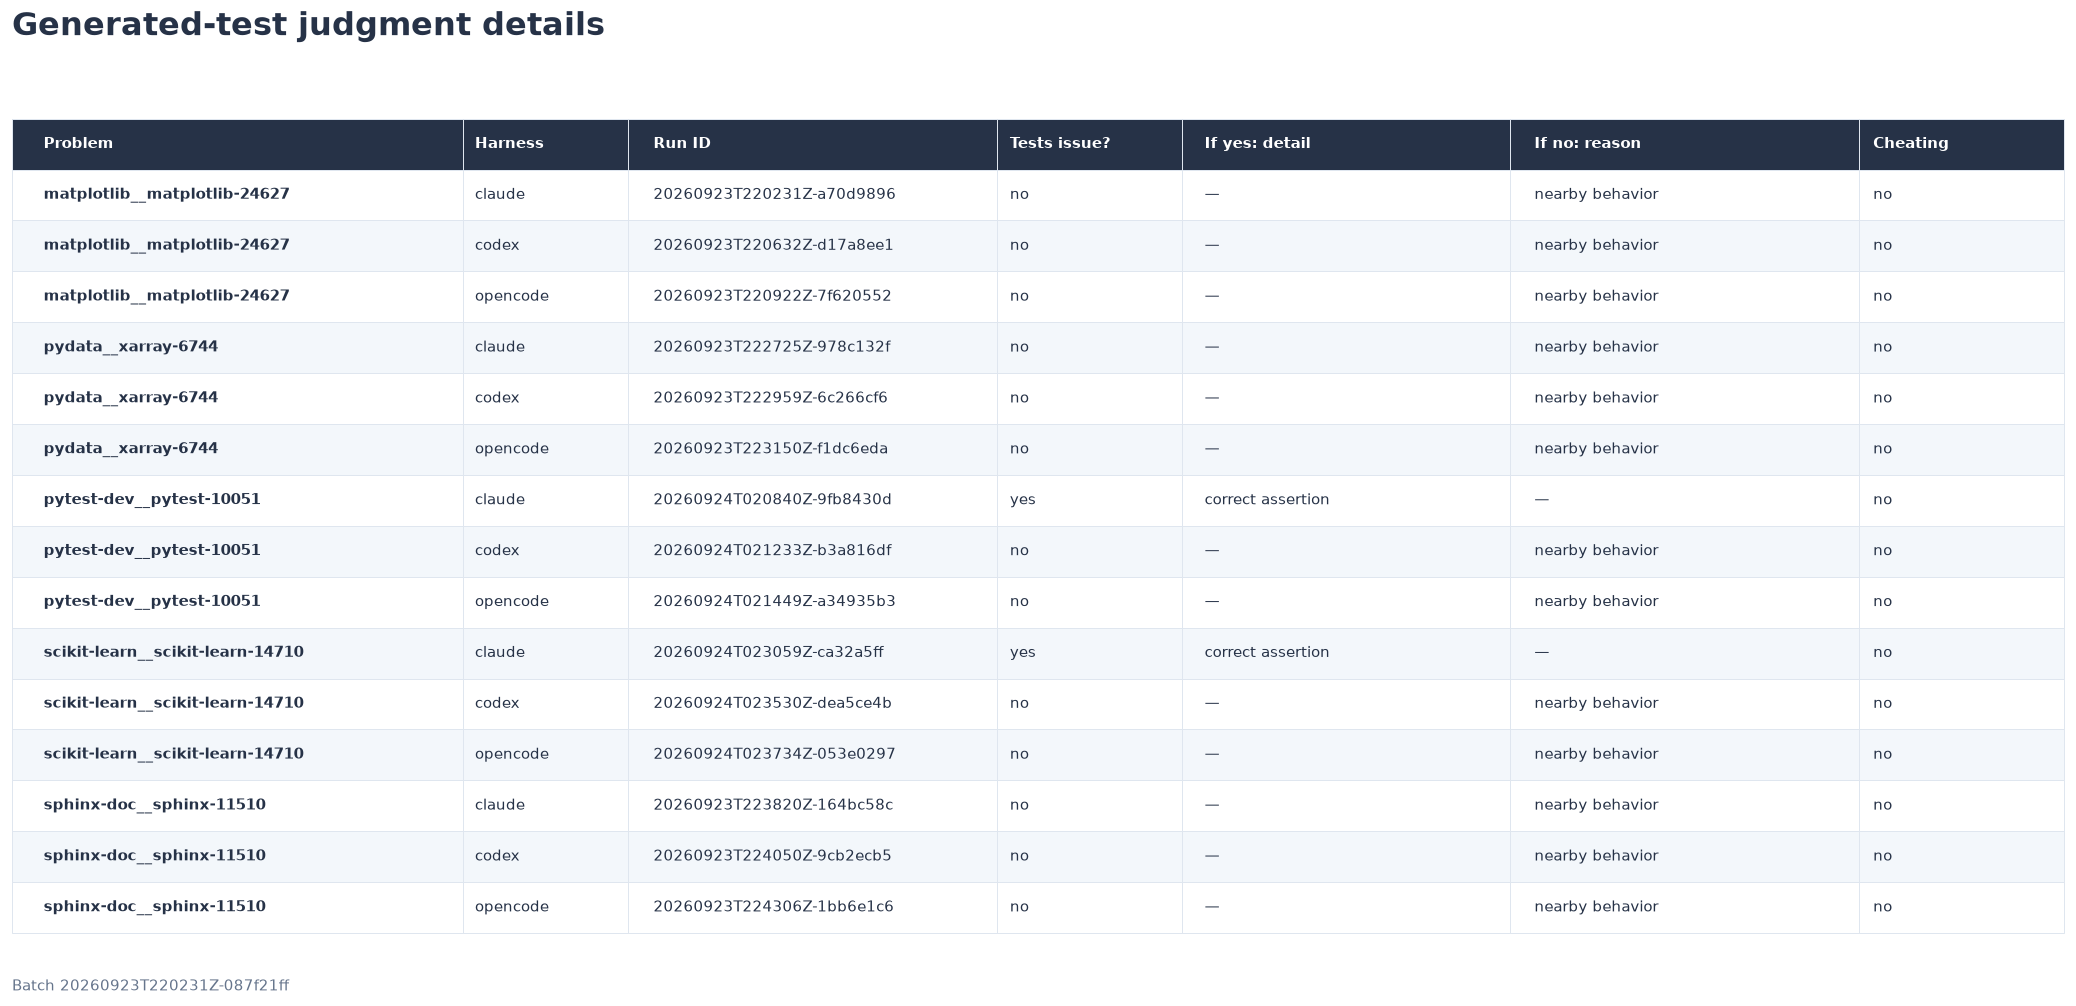

In [23]:
show_results_table(
    'Generated-test judgment details',
    ['Problem', 'Harness', 'Run ID', 'Tests issue?', 'If yes: detail',
     'If no: reason', 'Cheating'],
    [
        [r['problem'], r['harness'], r['run_id'], r['judge_outcome'],
         *((None, None, None) if r['judge_outcome'] == 'skipped' else (
             r.get('judge', {}).get('attempt_detail'),
             r.get('judge', {}).get('no_attempt_reason'),
             r.get('judge', {}).get('cheating')))]
        for r in sorted(judge_rows, key=lambda r: (r['problem'], r['harness']))
    ],
    [0.22, 0.08, 0.18, 0.09, 0.16, 0.17, 0.10], 8.7,
    PROJECT_ROOT / 'notebooks' / 'figures' / f'{BATCH_DIR.name}-judgments.png',
)

## Task classifications

The table reads the latest completed central classification for each problem in this batch. Classification describes the SWE-bench task itself, not the generated tests. A dash means the facet does not apply or no completed classification is saved.

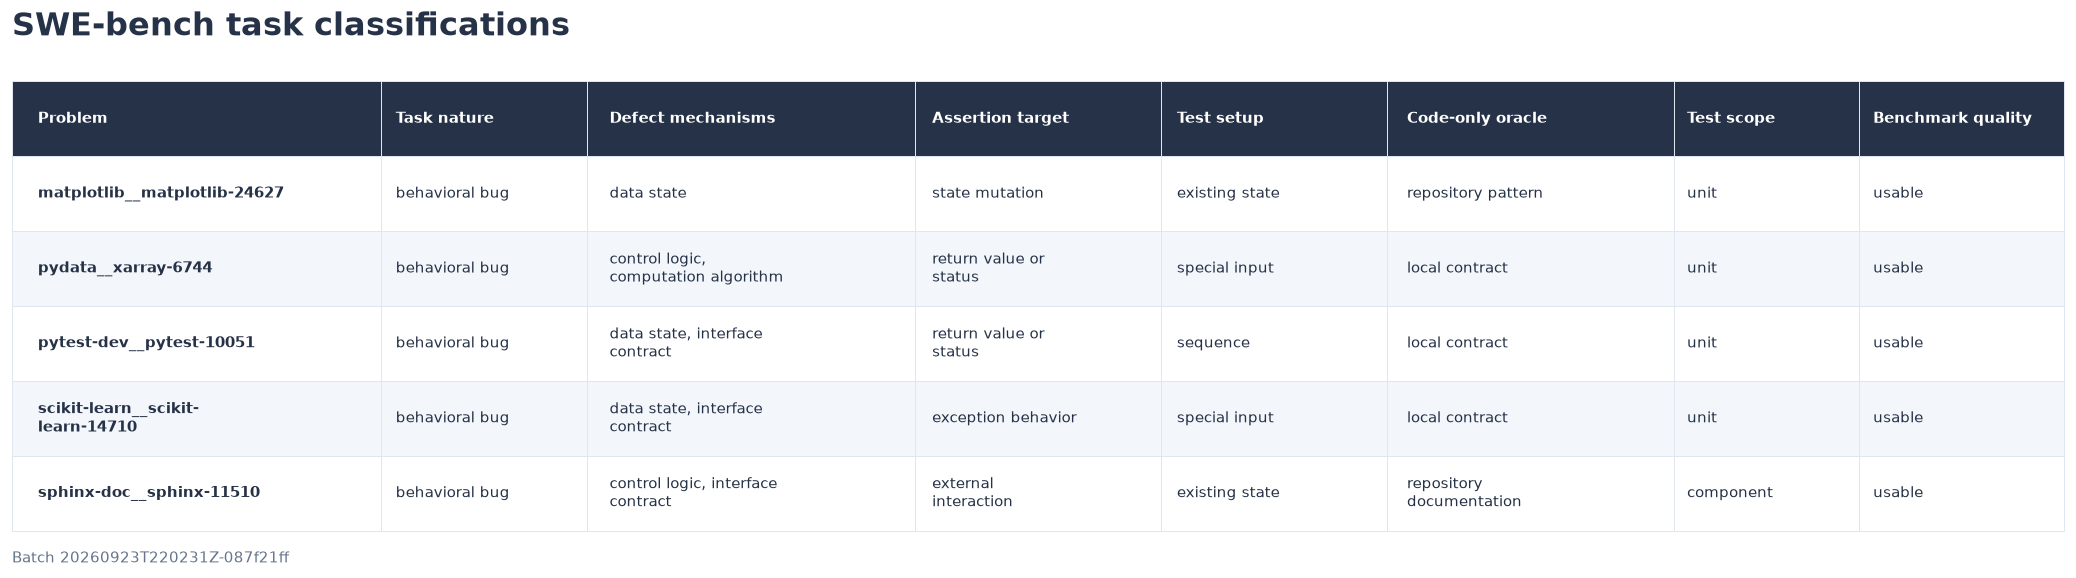

Classified problems: 5 / 5


In [24]:
classifications = {}
for problem in sorted({r['problem'] for r in rows}):
    attempts = sorted((PROJECT_ROOT / 'classifications' / problem).glob('*/classification.json'))
    for path in reversed(attempts):
        result = json.loads(path.read_text())['result']
        if result['status'] == 'completed':
            classifications[problem] = result
            break

show_results_table(
    'SWE-bench task classifications',
    ['Problem', 'Task nature', 'Defect mechanisms', 'Assertion target',
     'Test setup', 'Code-only oracle', 'Test scope', 'Benchmark quality'],
    [
        [problem, result.get('task_nature'), ', '.join(result.get('defect_mechanisms', [])) or None,
         result.get('primary_assertion_target'), result.get('required_test_setup'),
         result.get('code_only_oracle_availability'), result.get('required_test_scope'),
         result.get('benchmark_quality')]
        for problem in sorted({r['problem'] for r in rows})
        for result in [classifications.get(problem, {})]
    ],
    [0.18, 0.10, 0.16, 0.12, 0.11, 0.14, 0.09, 0.10], 4.8,
    PROJECT_ROOT / 'notebooks' / 'figures' / f'{BATCH_DIR.name}-classifications.png',
)
print(f'Classified problems: {len(classifications)} / {len({r["problem"] for r in rows})}')